# Exploration (EDA) — Projet immobilier (web scraping)

Ce notebook correspond à la partie **`NOTEBOOKS/exploration.ipynb`** demandée dans l’énoncé : *analyses et tests*.

Dataset utilisé : `scraping_clean.csv` (annonces nettoyées).

Objectifs EDA :
- Vérifier la qualité des données (types, NA, doublons)
- Comprendre la distribution des **prix**, **surfaces**, **pièces** et **prix/m²**
- Comparer les niveaux **par région** et **par ville**
- Tester des relations simples (corrélation surface ↔ prix)
- Produire quelques visuels de base (histogrammes, boxplots, scatter)


## 0) Imports & chargement

`scraping_clean.csv` dans un dossier `data/` à la racine du projet (recommandé), sinon ajuste le chemin.


In [29]:
from pathlib import Path
import pandas as pd

# 🔎 Détection automatique de la racine du projet (celle qui contient "data/")
here = Path.cwd()
PROJECT_DIR = None

for p in [here] + list(here.parents):
    if (p / "data").exists():
        PROJECT_DIR = p
        break

if PROJECT_DIR is None:
    raise RuntimeError("Impossible de trouver le dossier 'data/'")

DATA_DIR = PROJECT_DIR / "data"
CSV_PATH = DATA_DIR / "scraping_clean.csv"

print("PROJECT_DIR :", PROJECT_DIR)
print("CSV_PATH    :", CSV_PATH)
print("Exists      :", CSV_PATH.exists())

# Chargement
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df.head()



PROJECT_DIR : /Users/guillaume/Desktop/Projet_python_avancé/Projet_scraping_KEITA_PATIENT
CSV_PATH    : /Users/guillaume/Desktop/Projet_python_avancé/Projet_scraping_KEITA_PATIENT/data/scraping_clean.csv
Exists      : True


,region,source,raw_alt,titre,localisation,prix_extracted,surface_m2_extracted,rooms_extracted,code_postal_extracted,ville_extracted_cleaned,commune_from_cp,ville_finale,ville_agregee,marche_neuf_ancien,price_m2,nom_commune,code_insee
0,Hauts-de-France,logicimmo,Maison à vendre 184 000 € 4 pièces 3 chambres ...,NaN,NaN,184000.0,84.6,4.0,59179,FENAIN,FENAIN,FENAIN,FENAIN,ancien,2174.940898,FENAIN,59227
1,Hauts-de-France,logicimmo,Maison à vendre - neuf 183 280 € 3 pièces 2 ch...,NaN,NaN,183280.0,63.0,3.0,59157,BEAUVOIS,BEAUVOIS EN CAMBRESIS,BEAUVOIS EN CAMBRESIS,BEAUVOIS EN CAMBRESIS,neuf,2909.206349,BEAUVOIS EN CAMBRESIS,59063
2,Hauts-de-France,logicimmo,Appartement à vendre - neuf 540 000 € 2 pièces...,NaN,NaN,540000.0,47.3,2.0,62520,TOUQUET,LE TOUQUET PARIS PLAGE,LE TOUQUET PARIS PLAGE,LE TOUQUET PARIS PLAGE,neuf,11416.490486,LE TOUQUET PARIS PLAGE,62826
3,Hauts-de-France,logicimmo,Appartement à vendre - neuf 276 000 € 3 pièces...,NaN,NaN,276000.0,61.8,3.0,80000,AMIENS,AMIENS,AMIENS,AMIENS,neuf,4466.019417,AMIENS,80021
4,Hauts-de-France,logicimmo,Maison à vendre - neuf 289 000 € 3 pièces 2 ch...,NaN,NaN,289000.0,71.5,3.0,80000,AMIENS,AMIENS,AMIENS,AMIENS,neuf,4041.958042,AMIENS,80021


In [30]:
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
display(df.head())


Shape: (15332, 17)


,region,source,raw_alt,titre,localisation,prix_extracted,surface_m2_extracted,rooms_extracted,code_postal_extracted,ville_extracted_cleaned,commune_from_cp,ville_finale,ville_agregee,marche_neuf_ancien,price_m2,nom_commune,code_insee
0,Hauts-de-France,logicimmo,Maison à vendre 184 000 € 4 pièces 3 chambres ...,NaN,NaN,184000.0,84.6,4.0,59179,FENAIN,FENAIN,FENAIN,FENAIN,ancien,2174.940898,FENAIN,59227
1,Hauts-de-France,logicimmo,Maison à vendre - neuf 183 280 € 3 pièces 2 ch...,NaN,NaN,183280.0,63.0,3.0,59157,BEAUVOIS,BEAUVOIS EN CAMBRESIS,BEAUVOIS EN CAMBRESIS,BEAUVOIS EN CAMBRESIS,neuf,2909.206349,BEAUVOIS EN CAMBRESIS,59063
2,Hauts-de-France,logicimmo,Appartement à vendre - neuf 540 000 € 2 pièces...,NaN,NaN,540000.0,47.3,2.0,62520,TOUQUET,LE TOUQUET PARIS PLAGE,LE TOUQUET PARIS PLAGE,LE TOUQUET PARIS PLAGE,neuf,11416.490486,LE TOUQUET PARIS PLAGE,62826
3,Hauts-de-France,logicimmo,Appartement à vendre - neuf 276 000 € 3 pièces...,NaN,NaN,276000.0,61.8,3.0,80000,AMIENS,AMIENS,AMIENS,AMIENS,neuf,4466.019417,AMIENS,80021
4,Hauts-de-France,logicimmo,Maison à vendre - neuf 289 000 € 3 pièces 2 ch...,NaN,NaN,289000.0,71.5,3.0,80000,AMIENS,AMIENS,AMIENS,AMIENS,neuf,4041.958042,AMIENS,80021


## 1) Structure & qualité des données
- colonnes / types
- valeurs manquantes
- doublons


In [31]:
df.info()

print("\nColonnes:")
for c in df.columns:
    print(" -", c)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15332 entries, 0 to 15331
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   region                   15332 non-null  object 
 1   source                   15332 non-null  object 
 2   raw_alt                  15332 non-null  object 
 3   titre                    1171 non-null   object 
 4   localisation             1171 non-null   object 
 5   prix_extracted           15322 non-null  float64
 6   surface_m2_extracted     15295 non-null  float64
 7   rooms_extracted          14086 non-null  float64
 8   code_postal_extracted    15332 non-null  int64  
 9   ville_extracted_cleaned  15332 non-null  object 
 10  commune_from_cp          15332 non-null  object 
 11  ville_finale             15332 non-null  object 
 12  ville_agregee            15332 non-null  object 
 13  marche_neuf_ancien       15332 non-null  object 
 14  price_m2              

In [32]:
# % de NA par colonne
na_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
display(na_pct.to_frame("% NA"))

# Doublons exacts
print("Doublons (toutes colonnes):", df.duplicated().sum())


,% NA
titre,92.36
localisation,92.36
rooms_extracted,8.13
surface_m2_extracted,0.24
price_m2,0.24
prix_extracted,0.07
region,0.00
ville_finale,0.00
nom_commune,0.00
marche_neuf_ancien,0.00


Doublons (toutes colonnes): 434


## 2) Préparation minimale (cast + contrôles)
On s’assure que les variables numériques sont bien numériques et on crée une colonne **prix/m²** si besoin.


In [33]:
# Colonnes numériques attendues dans ton fichier
num_cols = [
    "prix_extracted",
    "surface_m2_extracted",
    "rooms_extracted",
    "code_postal_extracted",
    "price_m2",
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Calcul prix/m² si absent ou partiellement manquant
if "price_m2" not in df.columns:
    df["price_m2"] = df["prix_extracted"] / df["surface_m2_extracted"]
else:
    mask = df["price_m2"].isna() & df["prix_extracted"].notna() & df["surface_m2_extracted"].notna() & (df["surface_m2_extracted"] > 0)
    df.loc[mask, "price_m2"] = df.loc[mask, "prix_extracted"] / df.loc[mask, "surface_m2_extracted"]

# Filtre de base pour analyses (évite divisions par zéro / valeurs aberrantes grossières)
df_eda = df.copy()
df_eda = df_eda[(df_eda["prix_extracted"].notna()) & (df_eda["surface_m2_extracted"].notna())]
df_eda = df_eda[(df_eda["prix_extracted"] > 1000) & (df_eda["surface_m2_extracted"] > 5)]

print("Lignes conservées pour EDA:", df_eda.shape)
display(df_eda[["region","source","prix_extracted","surface_m2_extracted","rooms_extracted","ville_extracted_cleaned","price_m2"]].head())


Lignes conservées pour EDA: (15293, 17)


,region,source,prix_extracted,surface_m2_extracted,rooms_extracted,ville_extracted_cleaned,price_m2
0,Hauts-de-France,logicimmo,184000.0,84.6,4.0,FENAIN,2174.940898
1,Hauts-de-France,logicimmo,183280.0,63.0,3.0,BEAUVOIS,2909.206349
2,Hauts-de-France,logicimmo,540000.0,47.3,2.0,TOUQUET,11416.490486
3,Hauts-de-France,logicimmo,276000.0,61.8,3.0,AMIENS,4466.019417
4,Hauts-de-France,logicimmo,289000.0,71.5,3.0,AMIENS,4041.958042


## 3) Statistiques descriptives (prix, surface, pièces, prix/m²)


In [34]:
desc = df_eda[["prix_extracted","surface_m2_extracted","rooms_extracted","price_m2"]].describe().T
display(desc)


,count,mean,std,min,25%,50%,75%,max
prix_extracted,15293.0,360683.412476,336221.745672,19000.000000,204100.00,277000.000000,399000.000000,1.099800e+07
surface_m2_extracted,15293.0,85.264650,57.468764,7.000000,49.00,72.800000,99.400000,9.220000e+02
rooms_extracted,14065.0,3.655670,1.902027,1.000000,2.00,3.000000,4.000000,3.100000e+01
price_m2,15293.0,4556.870283,2644.207047,231.707317,3139.85,4140.526976,5436.363636,1.059190e+05


## 4) Visualisations de base
### 4.1 Histogrammes (prix, surface, prix/m²)
On peut utiliser une échelle log pour le prix/m² si nécessaire.


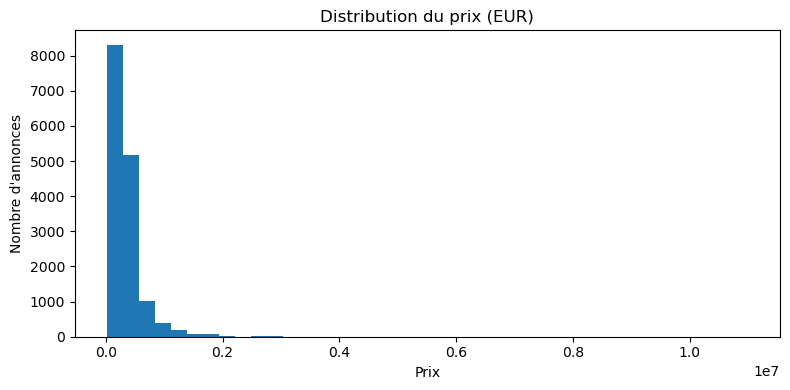

In [35]:
plt.figure(figsize=(8,4))
plt.hist(df_eda["prix_extracted"].dropna(), bins=40)
plt.title("Distribution du prix (EUR)")
plt.xlabel("Prix")
plt.ylabel("Nombre d'annonces")
plt.tight_layout()
plt.show()


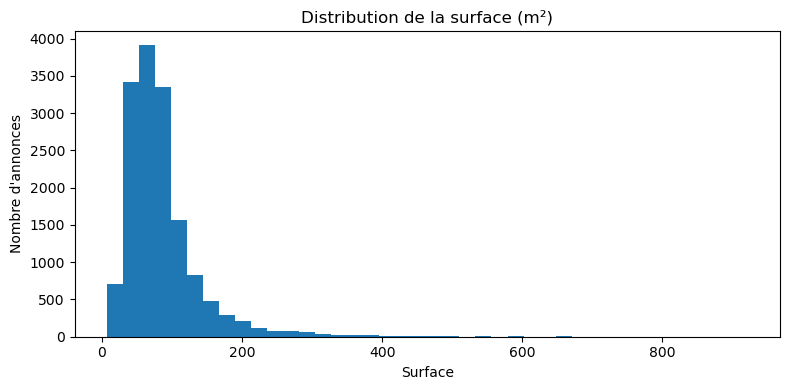

In [36]:
plt.figure(figsize=(8,4))
plt.hist(df_eda["surface_m2_extracted"].dropna(), bins=40)
plt.title("Distribution de la surface (m²)")
plt.xlabel("Surface")
plt.ylabel("Nombre d'annonces")
plt.tight_layout()
plt.show()


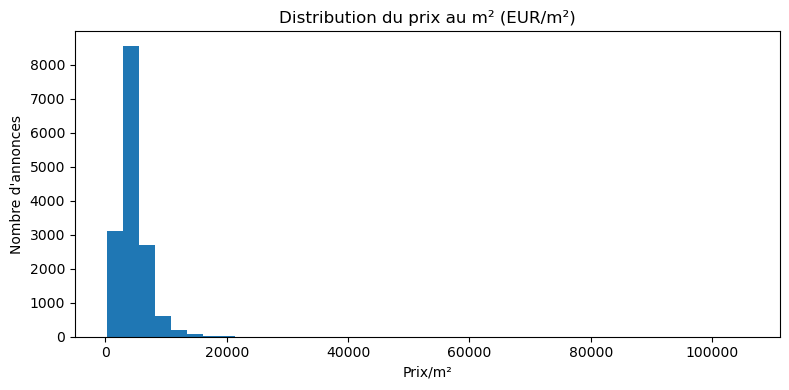

In [37]:
plt.figure(figsize=(8,4))
plt.hist(df_eda["price_m2"].dropna(), bins=40)
plt.title("Distribution du prix au m² (EUR/m²)")
plt.xlabel("Prix/m²")
plt.ylabel("Nombre d'annonces")
plt.tight_layout()
plt.show()


### 4.2 Boxplot — prix/m² par région (comparaison territoriale)


/var/folders/cr/t9msm2z90wd35cwk0q6jr5pw0000gn/T/ipykernel_36177/3574688948.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=regions_sorted, showfliers=False)


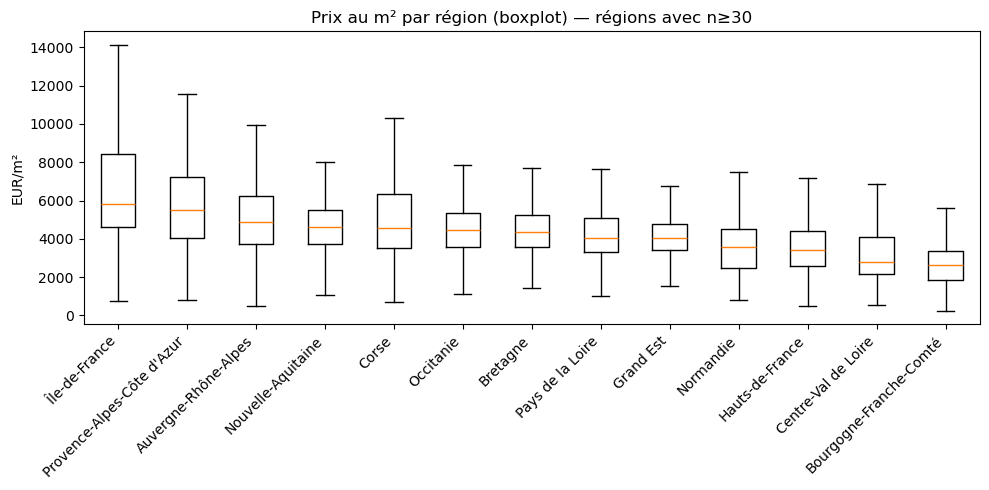

In [38]:
# On limite aux régions avec assez d'annonces
min_n = 30
counts = df_eda["region"].value_counts()
regions_keep = counts[counts >= min_n].index.tolist()
df_r = df_eda[df_eda["region"].isin(regions_keep)].copy()

regions_sorted = (
    df_r.groupby("region")["price_m2"].median().sort_values(ascending=False).index.tolist()
)

data = [df_r.loc[df_r["region"]==r, "price_m2"].dropna().values for r in regions_sorted]

plt.figure(figsize=(10,5))
plt.boxplot(data, labels=regions_sorted, showfliers=False)
plt.title("Prix au m² par région (boxplot) — régions avec n≥30")
plt.ylabel("EUR/m²")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 4.3 Corrélation surface ↔ prix (scatter)
Objectif : vérifier si plus de surface implique mécaniquement plus de prix, et observer la dispersion.


Corrélation (Pearson) prix vs surface: 0.56


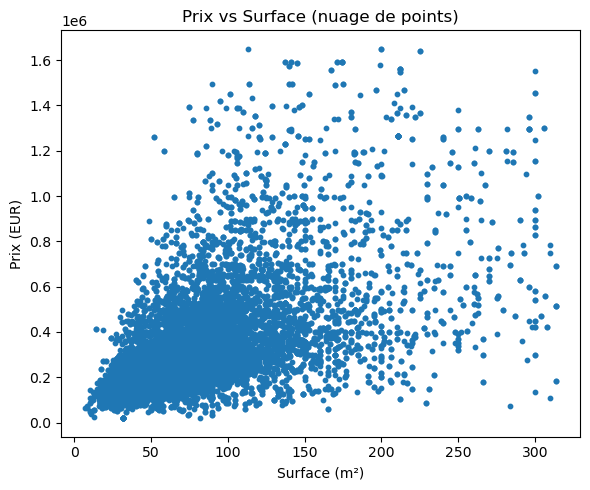

In [39]:
tmp = df_eda[["prix_extracted","surface_m2_extracted"]].dropna().copy()

# Option: limiter les extrêmes pour rendre le nuage lisible
q_price = tmp["prix_extracted"].quantile(0.99)
q_surf = tmp["surface_m2_extracted"].quantile(0.99)
tmp = tmp[(tmp["prix_extracted"] <= q_price) & (tmp["surface_m2_extracted"] <= q_surf)]

corr = tmp["prix_extracted"].corr(tmp["surface_m2_extracted"], method="pearson")
print("Corrélation (Pearson) prix vs surface:", round(float(corr), 3))

plt.figure(figsize=(6,5))
plt.scatter(tmp["surface_m2_extracted"], tmp["prix_extracted"], s=10)
plt.title("Prix vs Surface (nuage de points)")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix (EUR)")
plt.tight_layout()
plt.show()


## 5) Agrégations — tendances par région et par ville
On calcule des statistiques simples pour répondre à la problématique : **variation du prix/m² selon localisation**.


In [40]:
# Prix/m² par région
reg_stats = (
    df_eda.groupby("region")
    .agg(n=("price_m2","size"), price_m2_median=("price_m2","median"), price_m2_mean=("price_m2","mean"))
    .sort_values("price_m2_median", ascending=False)
)
display(reg_stats.head(15))


,n,price_m2_median,price_m2_mean
region,,,
Île-de-France,1195,5829.268293,6657.910191
Provence-Alpes-Côte d'Azur,1186,5481.016722,5883.064251
Auvergne-Rhône-Alpes,1135,4870.588235,5472.087553
Nouvelle-Aquitaine,1156,4632.862644,4863.367379
Corse,1152,4566.999440,5011.749251
Occitanie,1226,4447.775000,4611.136302
Bretagne,1148,4375.100000,4559.310179
Pays de la Loire,1215,4050.000000,4300.679115
Grand Est,1215,4029.835234,4165.931199


In [41]:
# Top villes (si suffisamment d'annonces)
if "ville_extracted_cleaned" in df_eda.columns:
    city_stats = (
        df_eda.groupby(["region","ville_extracted_cleaned"]) 
        .agg(n=("price_m2","size"), price_m2_median=("price_m2","median"), price_m2_mean=("price_m2","mean"))
        .reset_index()
    )
    city_stats = city_stats[city_stats["n"] >= 10].sort_values("price_m2_median", ascending=False)
    display(city_stats.head(20))
else:
    print("Colonne ville_extracted_cleaned absente : section villes ignorée.")


,region,ville_extracted_cleaned,n,price_m2_median,price_m2_mean
2249,Provence-Alpes-Côte d'Azur,CAP,12,15409.301347,15586.151357
1445,Hauts-de-France,TOUQUET,11,14483.333333,15043.492013
56,Auvergne-Rhône-Alpes,COURCHEVEL,12,13720.559285,13396.969120
2552,Île-de-France,ÈME,123,11375.000000,11934.201320
111,Auvergne-Rhône-Alpes,MORZINE,10,11247.803163,10982.896312
2492,Île-de-France,PARIS,138,9487.411056,9662.883389
986,Corse,PRUGNA,17,9141.176471,8529.908257
896,Corse,ALBITRECCIA,14,9127.439724,8566.300067
2532,Île-de-France,VANVES,14,9117.363636,8899.910887
80,Auvergne-Rhône-Alpes,GETS,14,8931.777778,8826.703093


## 5bis) Géolocalisation (adresse → latitude/longitude)


In [42]:
# Dépendances (à installer si besoin):
# pip install geopy

import time
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# 1) Choisir les colonnes à utiliser pour l'adresse
col_city = "ville_extracted_cleaned" if "ville_extracted_cleaned" in df.columns else None
col_cp = "code_postal_extracted" if "code_postal_extracted" in df.columns else None

print("Ville:", col_city, "| CP:", col_cp)

def build_address(row):
    parts = []
    if col_city and pd.notna(row.get(col_city)):
        parts.append(str(row.get(col_city)).strip())
    if col_cp and pd.notna(row.get(col_cp)):
        try:
            parts.append(str(int(float(row.get(col_cp)))))
        except Exception:
            parts.append(str(row.get(col_cp)).strip())
    parts.append("France")
    addr = ", ".join([p for p in parts if p])
    return addr if addr != "France" else None

# 2) Préparer la liste d'adresses uniques
df_geo = df_eda.copy()
df_geo["address"] = df_geo.apply(build_address, axis=1)
addresses = df_geo["address"].dropna().drop_duplicates().tolist()
print("Adresses uniques à géocoder:", len(addresses))


Ville: ville_extracted_cleaned | CP: code_postal_extracted
Adresses uniques à géocoder: 2455


In [43]:
# 3) Géocodage avec cache disque (recommandé)
# On sauvegarde un cache CSV pour reprendre si ça coupe.

CACHE_PATH = DATA_DIR / "geocode_cache.csv"

if CACHE_PATH.exists():
    cache = pd.read_csv(CACHE_PATH)
    cache = cache.dropna(subset=["address"]).drop_duplicates(subset=["address"])
    geocode_cache = dict(zip(cache["address"], zip(cache["lat"], cache["lon"])))
    print("Cache chargé:", len(geocode_cache))
else:
    geocode_cache = {}
    print("Pas de cache existant — un nouveau sera créé.")

geolocator = Nominatim(user_agent="immobilier_eda_geocoder")
# 1 requête / seconde (safe). Mets 1.2–1.5 si tu veux être plus prudent.
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.0, return_value_on_exception=None)

to_process = [a for a in addresses if a not in geocode_cache]
print("À géocoder (nouveau):", len(to_process))

# ⚠️ Si tu as des milliers d'adresses, commence par un échantillon:
# to_process = to_process[:200]

for i, addr in enumerate(to_process, 1):
    loc = geocode(addr)
    if loc is not None:
        lat, lon = loc.latitude, loc.longitude
    else:
        lat, lon = np.nan, np.nan
    geocode_cache[addr] = (lat, lon)

    # Sauvegarde incrémentale toutes les 50 adresses
    if i % 50 == 0:
        df_cache = pd.DataFrame([{"address": k, "lat": v[0], "lon": v[1]} for k, v in geocode_cache.items()])
        df_cache.to_csv(CACHE_PATH, index=False)
        print(f"Sauvegarde cache: {i}/{len(to_process)}")

# Sauvegarde finale
df_cache = pd.DataFrame([{"address": k, "lat": v[0], "lon": v[1]} for k, v in geocode_cache.items()])
df_cache.to_csv(CACHE_PATH, index=False)
print("Cache écrit:", CACHE_PATH)


Cache chargé: 2461
À géocoder (nouveau): 0
Cache écrit: /Users/guillaume/Desktop/Projet_python_avancé/Projet_scraping_KEITA_PATIENT/data/geocode_cache.csv


In [44]:
# 4) Joindre lat/lon au dataset + export
cache_df = pd.read_csv(CACHE_PATH)
df_geo = df_geo.merge(cache_df, on="address", how="left")

geocoded_pct = df_geo[["lat","lon"]].notna().all(axis=1).mean() * 100
print("% d'annonces géocodées:", round(float(geocoded_pct), 2), "%")
display(df_geo[["region","ville_extracted_cleaned","code_postal_extracted","address","lat","lon"]].head(10))

OUT_GEO = DATA_DIR / "annonces_clean_geocoded.csv"
df_geo.to_csv(OUT_GEO, index=False)
print("Export géocodé:", OUT_GEO)


% d'annonces géocodées: 91.67 %


,region,ville_extracted_cleaned,code_postal_extracted,address,lat,lon
0,Hauts-de-France,FENAIN,59179,"FENAIN, 59179, France",50.367000,3.299150
1,Hauts-de-France,BEAUVOIS,59157,"BEAUVOIS, 59157, France",50.374280,2.233510
2,Hauts-de-France,TOUQUET,62520,"TOUQUET, 62520, France",50.520008,1.586453
3,Hauts-de-France,AMIENS,80000,"AMIENS, 80000, France",49.890560,2.308199
4,Hauts-de-France,AMIENS,80000,"AMIENS, 80000, France",49.890560,2.308199
5,Hauts-de-France,VALENCIENNES,59300,"VALENCIENNES, 59300, France",50.357932,3.523485
6,Hauts-de-France,AMIENS,80000,"AMIENS, 80000, France",49.890560,2.308199
7,Hauts-de-France,AMIENS,80000,"AMIENS, 80000, France",49.890560,2.308199
8,Hauts-de-France,ARRAS,62000,"ARRAS, 62000, France",50.291048,2.777221
9,Hauts-de-France,ARRAS,62000,"ARRAS, 62000, France",50.291048,2.777221


Export géocodé: /Users/guillaume/Desktop/Projet_python_avancé/Projet_scraping_KEITA_PATIENT/data/annonces_clean_geocoded.csv


 Vérification rapide sur une mini-carte (Folium)



In [45]:
# pip install folium
import folium

pts = df_geo.dropna(subset=["lat","lon"]).copy()
if len(pts) == 0:
    print("Aucun point géocodé à afficher.")
else:
    sample = pts.sample(n=min(200, len(pts)), random_state=42)
    m = folium.Map(location=[46.5, 2.5], zoom_start=5)
    for _, r in sample.iterrows():
        folium.CircleMarker(
            location=[r["lat"], r["lon"]],
            radius=3,
            popup=f"{r.get('ville_extracted_cleaned','')} — {r.get('prix_extracted', np.nan)} € — {round(r.get('price_m2', np.nan), 0)} €/m²"
        ).add_to(m)
    m


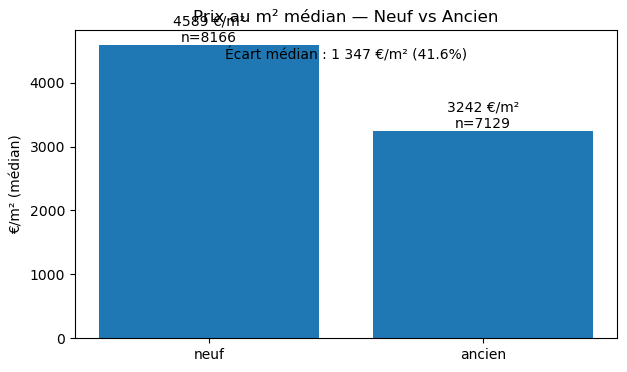

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

market_col = "marche_neuf_ancien"        # ou "neuf_ancien" si tu l'as déjà
price_m2_col = "price_m2"  # adapte si besoin

tmp = df[[market_col, price_m2_col]].dropna()
tmp = tmp[tmp[market_col].isin(["neuf", "ancien"])]

# Sécurité : il faut un minimum d'observations
if tmp.empty or tmp[market_col].nunique() < 2:
    print("Pas assez de données pour comparer Neuf vs Ancien.")
else:
    stats = (tmp.groupby(market_col)[price_m2_col]
               .agg(median="median", mean="mean", n="size")
               .reindex(["neuf","ancien"])
               .reset_index())

    # Calcul écart
    pm2_neuf = stats.loc[stats[market_col]=="neuf", "median"].values[0]
    pm2_ancien = stats.loc[stats[market_col]=="ancien", "median"].values[0]
    ecart = pm2_neuf - pm2_ancien
    ecart_pct = (ecart / pm2_ancien) * 100 if pm2_ancien else np.nan

    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(stats[market_col], stats["median"])
    ax.set_title("Prix au m² médian — Neuf vs Ancien")
    ax.set_xlabel("")
    ax.set_ylabel("€/m² (médian)")

    # Annotations (médianes + effectifs)
    for i, row in stats.iterrows():
        ax.text(i, row["median"], f"{row['median']:.0f} €/m²\nn={int(row['n'])}",
                ha="center", va="bottom")

    ax.text(0.5, max(stats["median"]) * 0.95,
            f"Écart médian : {ecart:,.0f} €/m² ({ecart_pct:.1f}%)".replace(",", " "),
            ha="center")

    plt.show()


/var/folders/cr/t9msm2z90wd35cwk0q6jr5pw0000gn/T/ipykernel_36177/2879302696.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_neuf, data_ancien], labels=["Neuf", "Ancien"], showfliers=False)


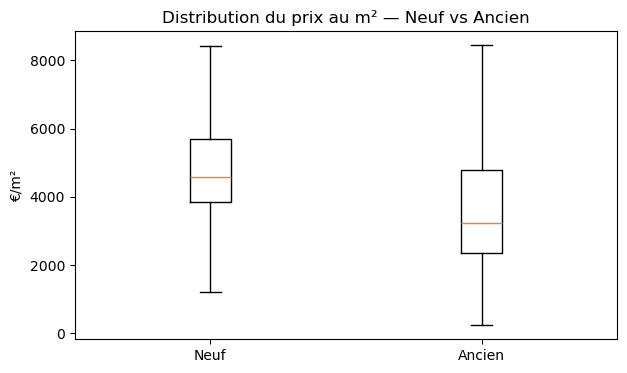

In [47]:
import matplotlib.pyplot as plt

market_col = "marche_neuf_ancien"
price_m2_col = "price_m2"

tmp = df[[market_col, price_m2_col]].dropna()
tmp = tmp[tmp[market_col].isin(["neuf", "ancien"])]

if tmp.empty or tmp[market_col].nunique() < 2:
    print("Pas assez de données pour un boxplot Neuf vs Ancien.")
else:
    data_neuf = tmp.loc[tmp[market_col]=="neuf", price_m2_col].values
    data_ancien = tmp.loc[tmp[market_col]=="ancien", price_m2_col].values

    fig, ax = plt.subplots(figsize=(7,4))
    ax.boxplot([data_neuf, data_ancien], labels=["Neuf", "Ancien"], showfliers=False)
    ax.set_title("Distribution du prix au m² — Neuf vs Ancien")
    ax.set_ylabel("€/m²")
    plt.show()


In [48]:
MIN_ANNONCES = 20  # seuil minimal par ville (ajuste si besoin)

df_city = df.dropna(subset=["region", "ville_finale", "price_m2"])


In [49]:
# Nombre d'annonces par région / ville
counts = (
    df_city
    .groupby(["region", "ville_finale"])
    .size()
    .reset_index(name="n_annonces")
)

# On garde uniquement les villes suffisamment représentées
big_cities = counts[counts["n_annonces"] >= MIN_ANNONCES]

df_big = df_city.merge(
    big_cities[["region", "ville_finale"]],
    on=["region", "ville_finale"],
    how="inner"
)

df_big.head()


,region,source,raw_alt,titre,localisation,prix_extracted,surface_m2_extracted,rooms_extracted,code_postal_extracted,ville_extracted_cleaned,commune_from_cp,ville_finale,ville_agregee,marche_neuf_ancien,price_m2,nom_commune,code_insee
0,Hauts-de-France,logicimmo,Appartement à vendre - neuf 276 000 € 3 pièces...,NaN,NaN,276000.0,61.8,3.0,80000,AMIENS,AMIENS,AMIENS,AMIENS,neuf,4466.019417,AMIENS,80021
1,Hauts-de-France,logicimmo,Maison à vendre - neuf 289 000 € 3 pièces 2 ch...,NaN,NaN,289000.0,71.5,3.0,80000,AMIENS,AMIENS,AMIENS,AMIENS,neuf,4041.958042,AMIENS,80021
2,Hauts-de-France,logicimmo,Maison à vendre - neuf 339 000 € 4 pièces 3 ch...,NaN,NaN,339000.0,85.6,4.0,80000,AMIENS,AMIENS,AMIENS,AMIENS,neuf,3960.280374,AMIENS,80021
3,Hauts-de-France,logicimmo,Appartement à vendre - neuf 220 000 € 2 pièces...,NaN,NaN,220000.0,46.8,2.0,80000,AMIENS,AMIENS,AMIENS,AMIENS,neuf,4700.854701,AMIENS,80021
4,Hauts-de-France,logicimmo,Appartement à vendre - neuf 228 000 € 2 pièces...,NaN,NaN,228000.0,49.9,2.0,62600,MER,BERCK,BERCK,BERCK,neuf,4569.138277,BERCK,62108


In [50]:
stats_city = (
    df_big
    .groupby(["region", "ville_finale"])
    .agg(
        price_m2_median=("price_m2", "median"),
        n=("price_m2", "size")
    )
    .reset_index()
)

stats_city.head()


,region,ville_finale,price_m2_median,n
0,Auvergne-Rhône-Alpes,AIX LES BAINS,6250.000000,46
1,Auvergne-Rhône-Alpes,ALLINGES,5220.478314,36
2,Auvergne-Rhône-Alpes,AMBILLY,5604.545455,30
3,Auvergne-Rhône-Alpes,ARCHAMPS,6681.818182,42
4,Auvergne-Rhône-Alpes,ARNAS,4211.882981,24


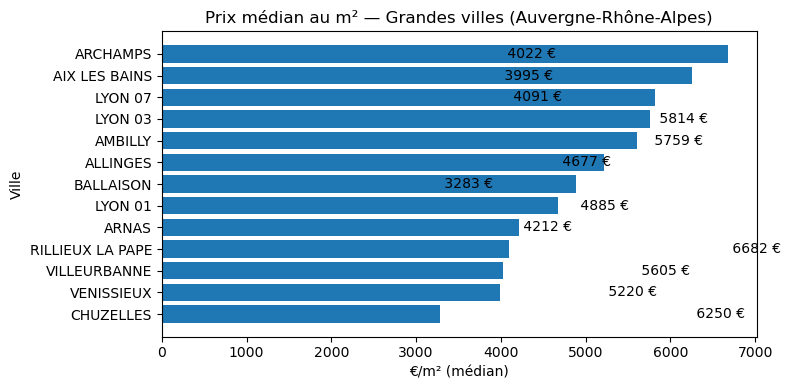

/var/folders/cr/t9msm2z90wd35cwk0q6jr5pw0000gn/T/ipykernel_36177/305043288.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


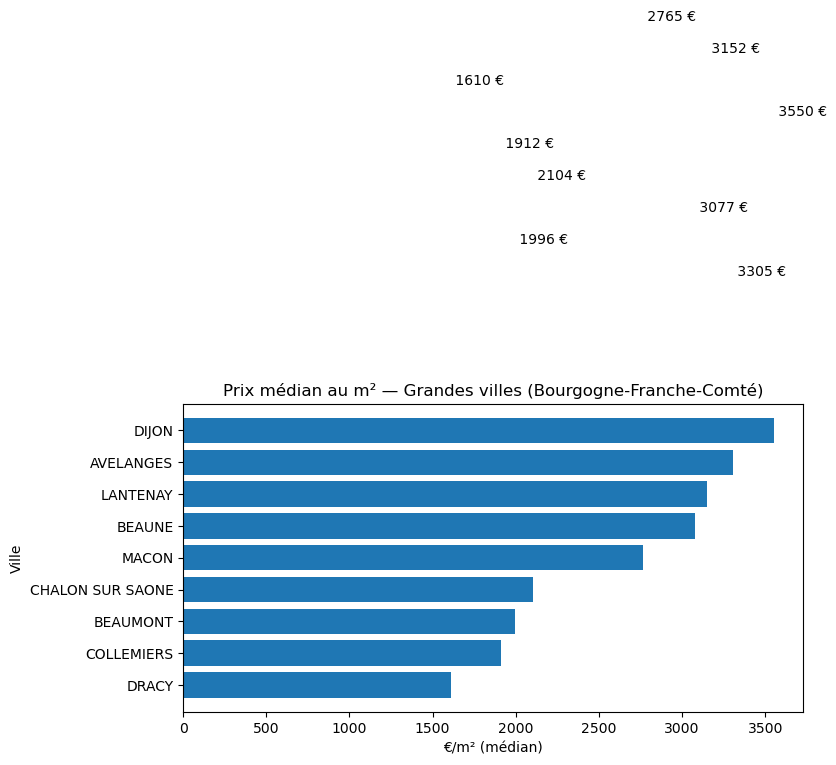

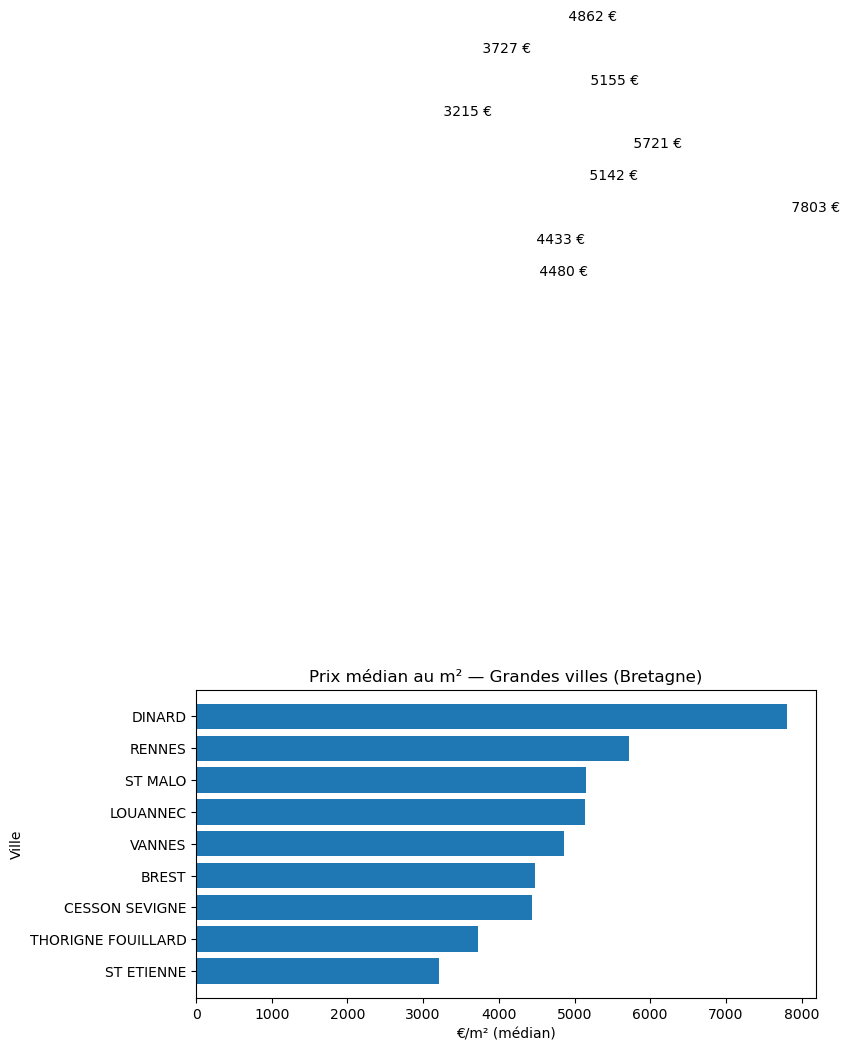

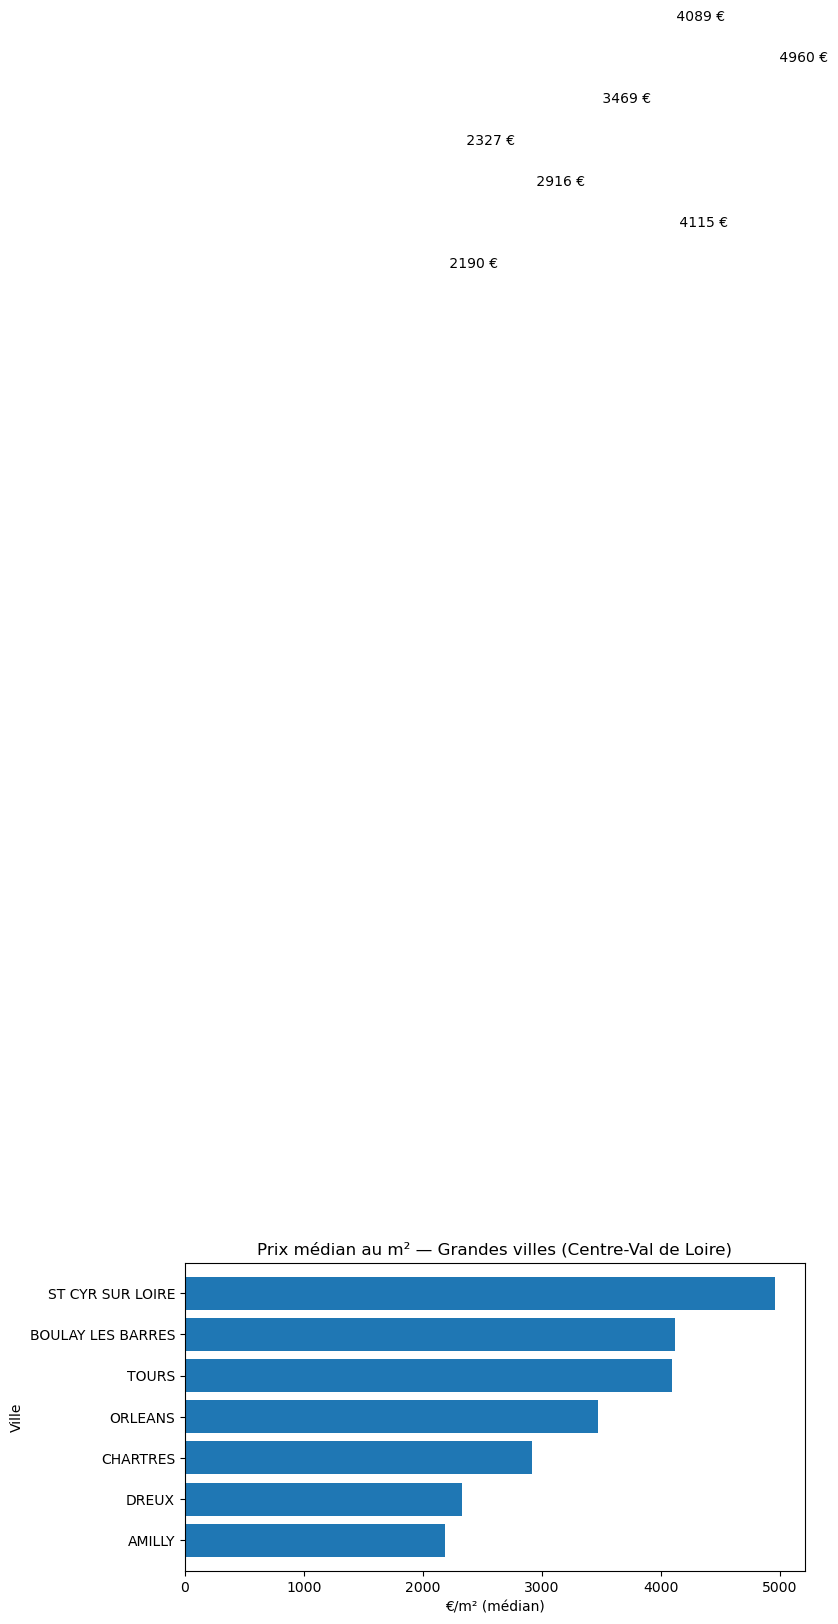

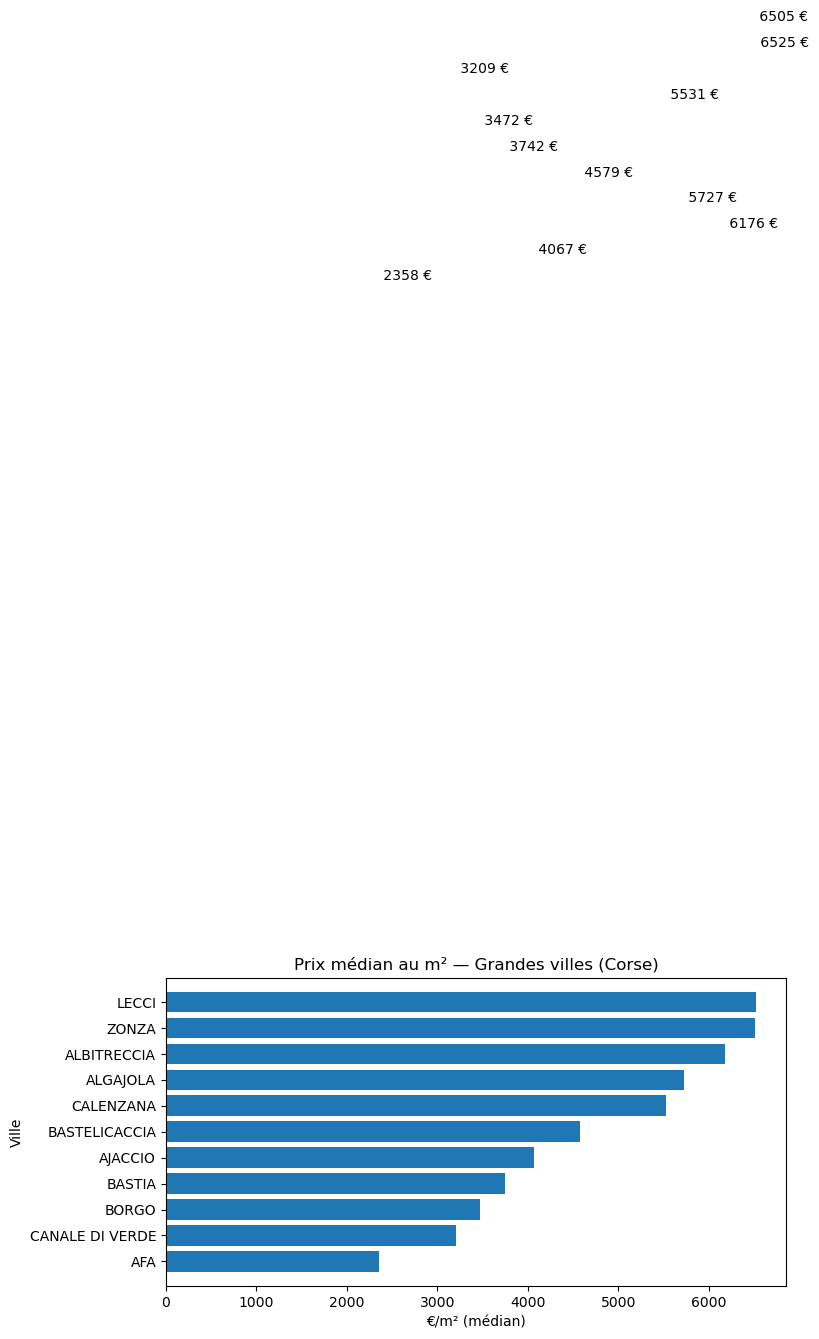

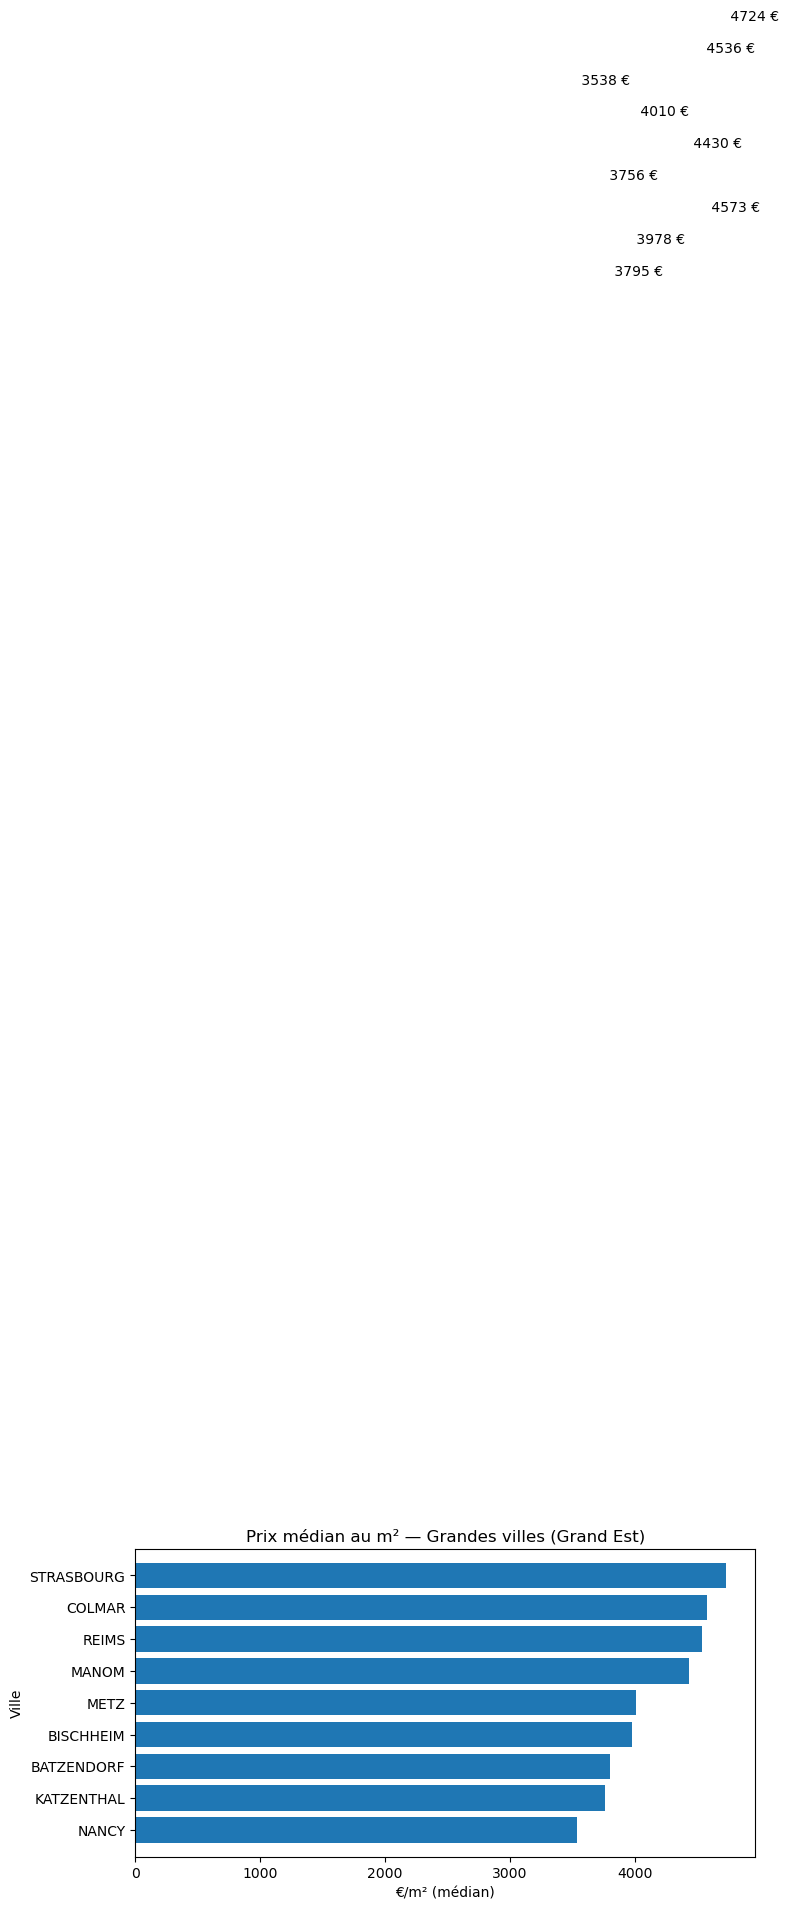

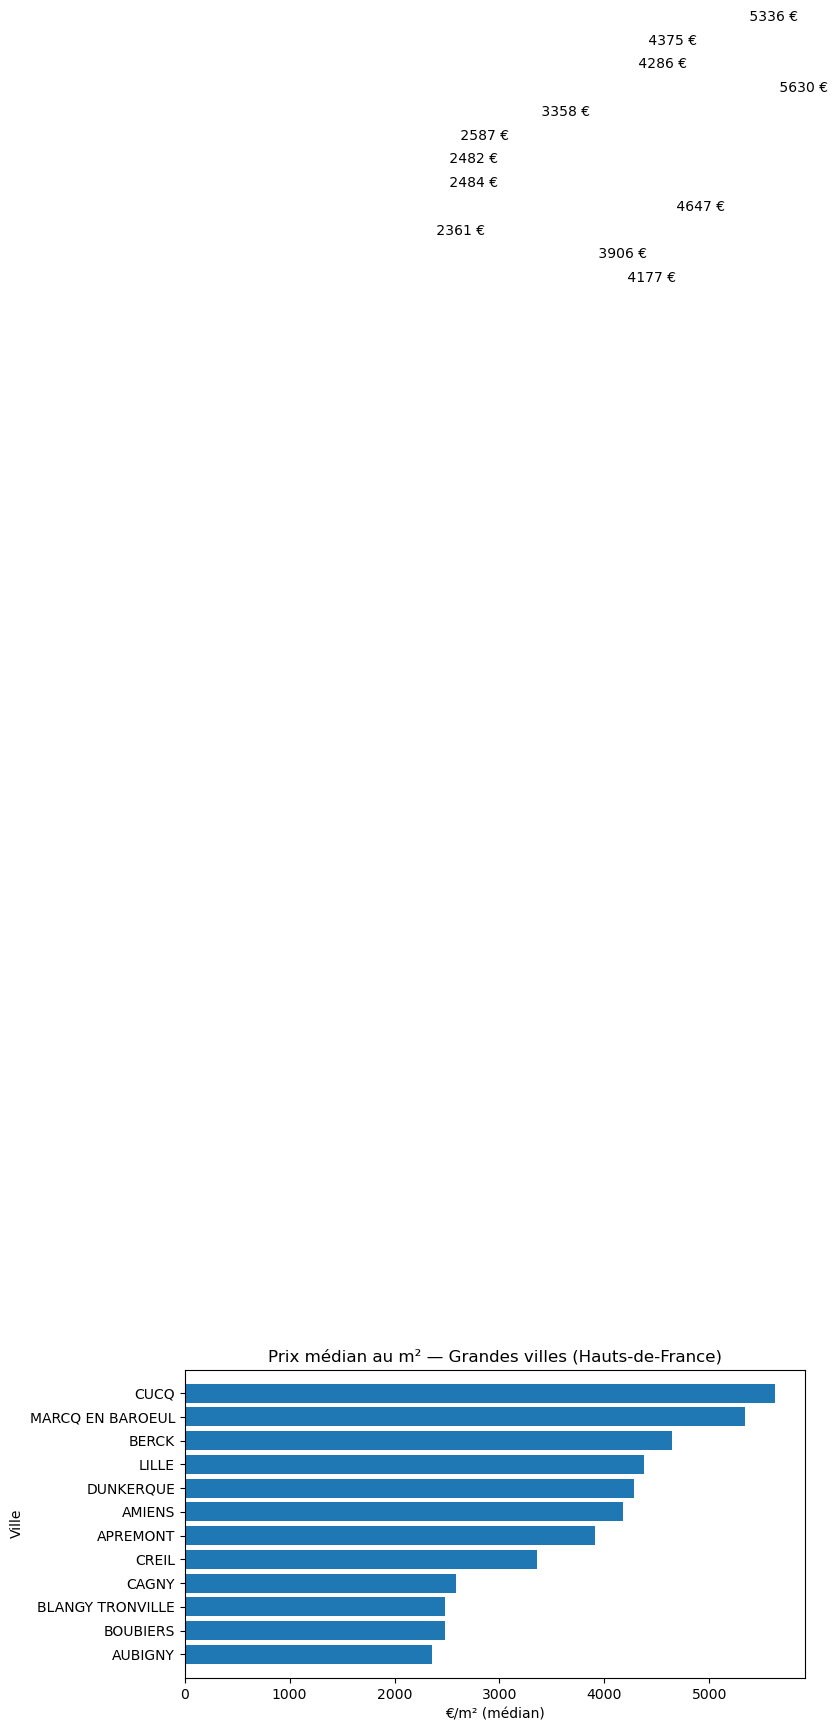

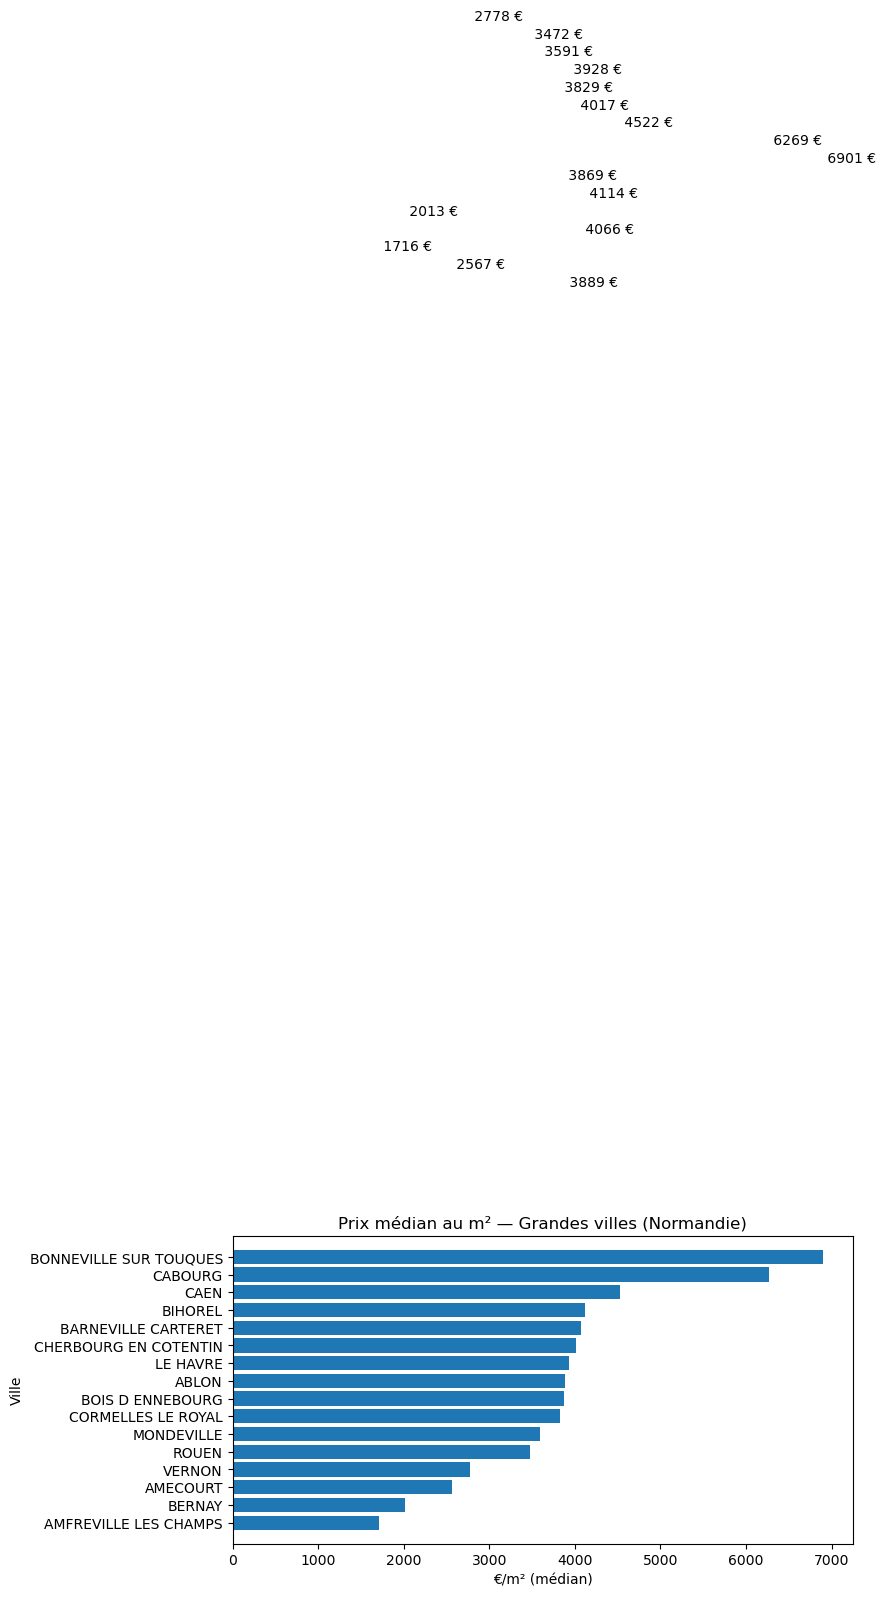

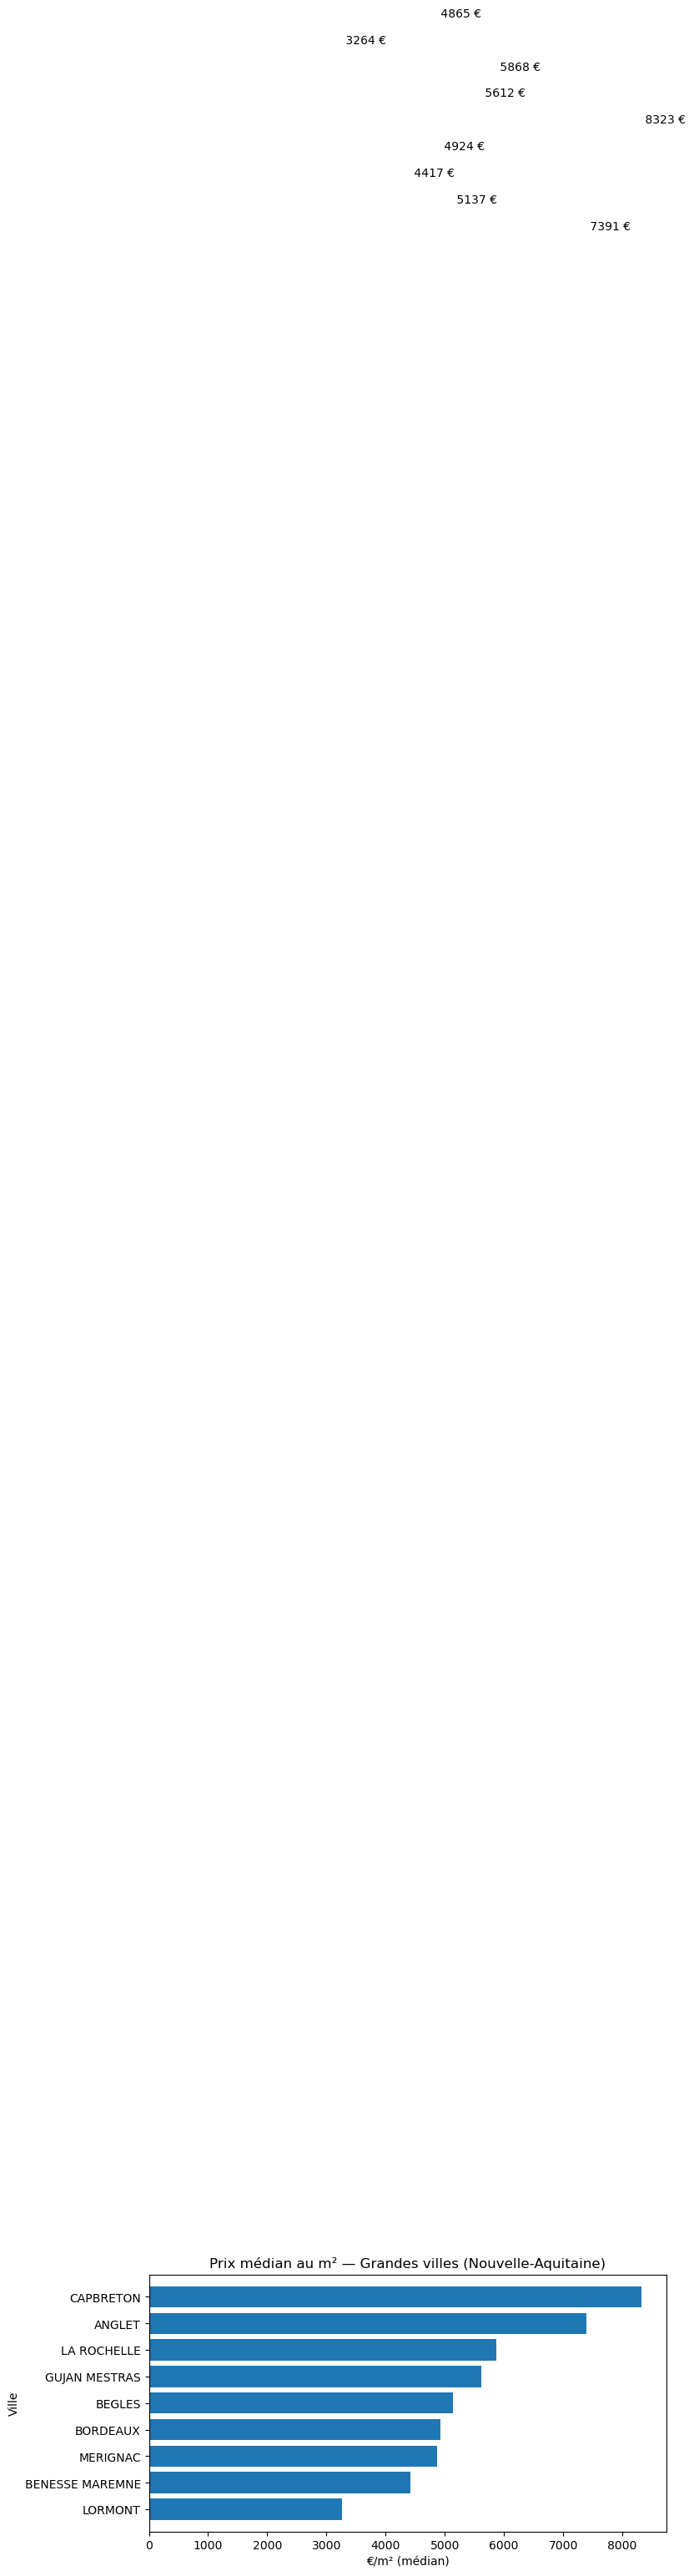

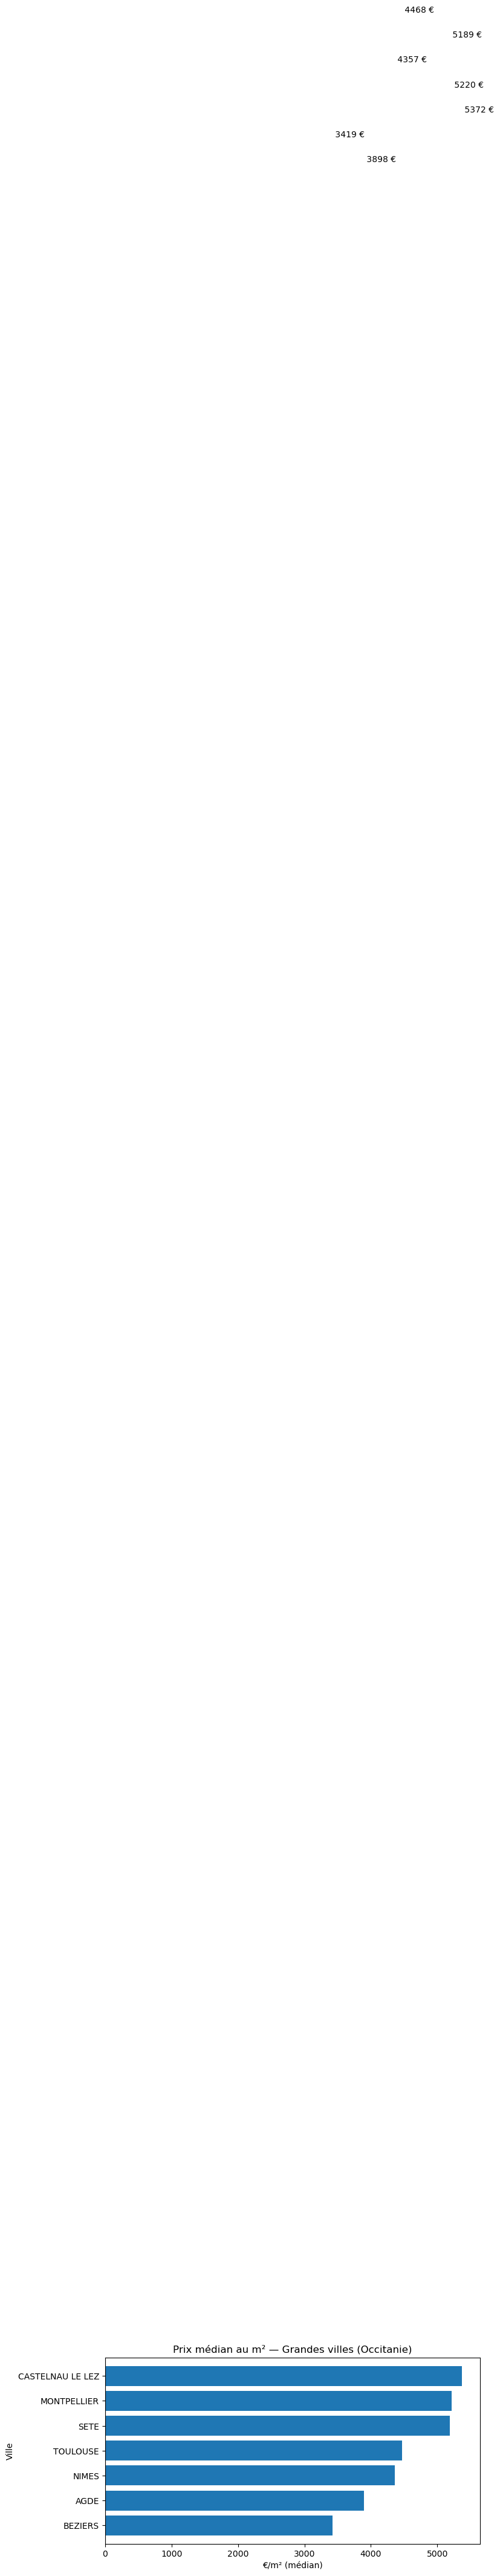

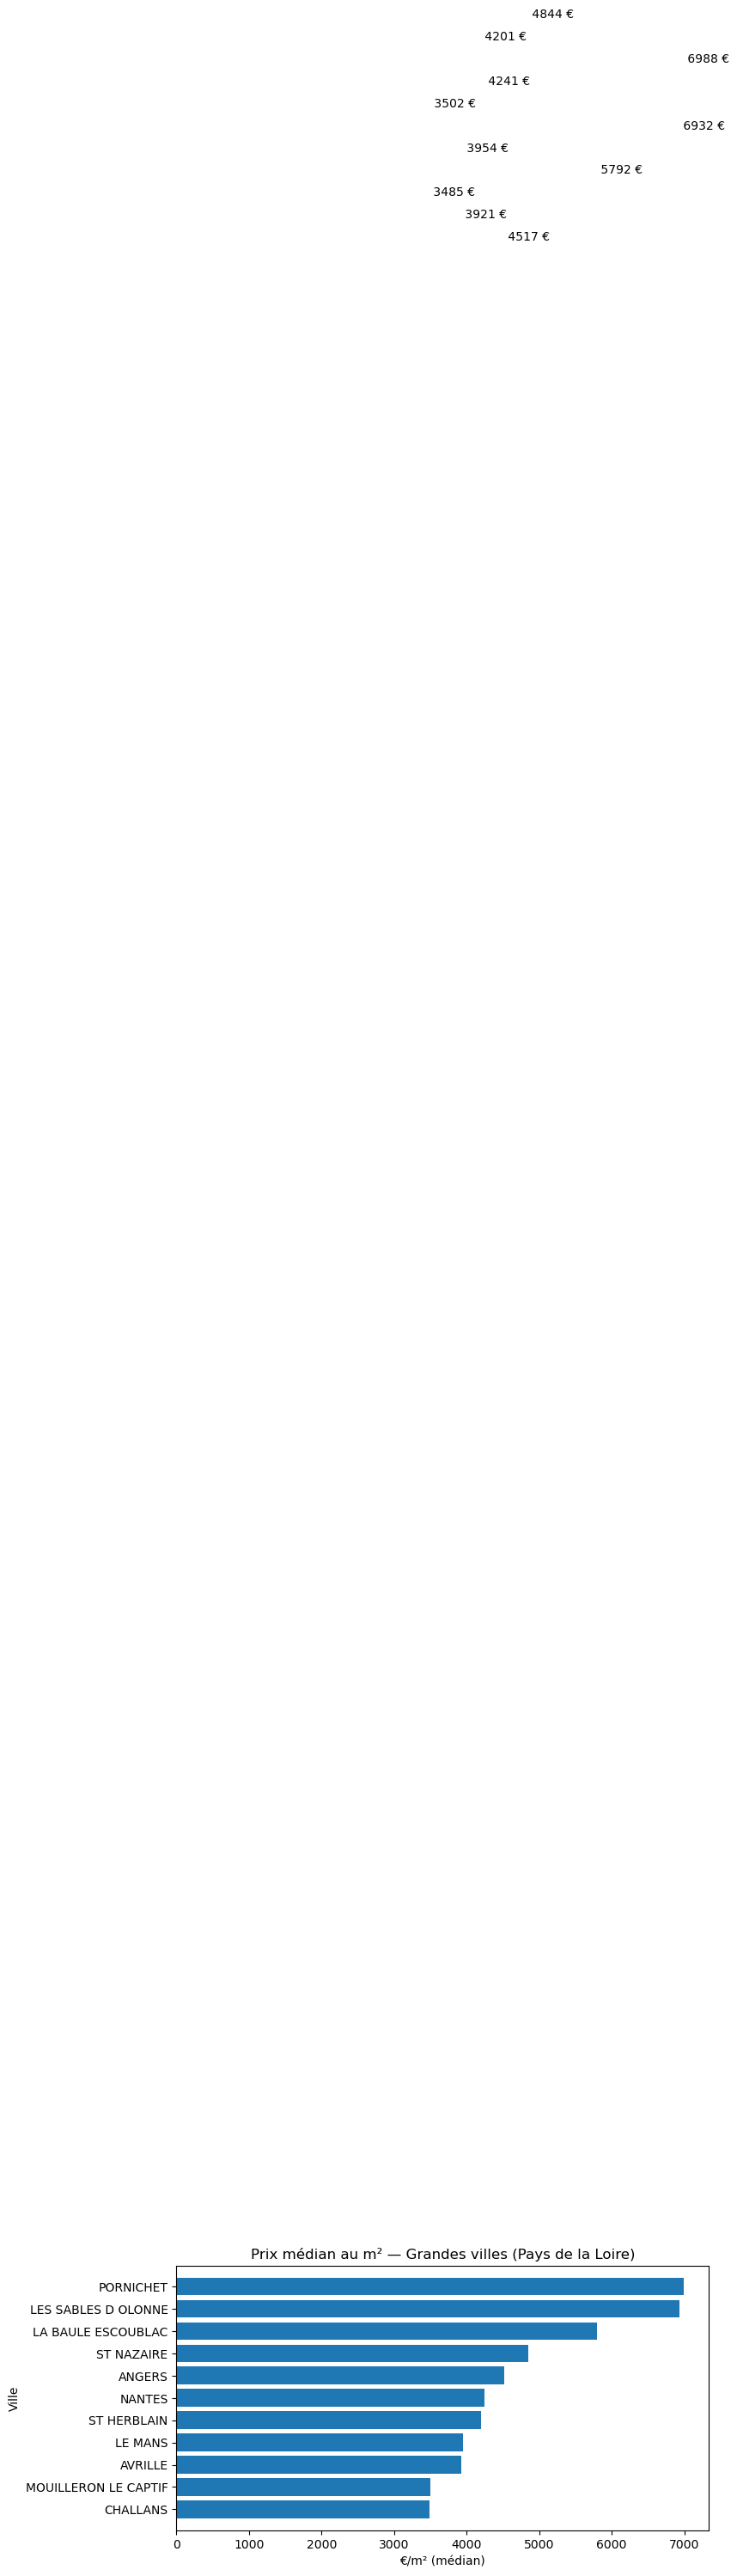

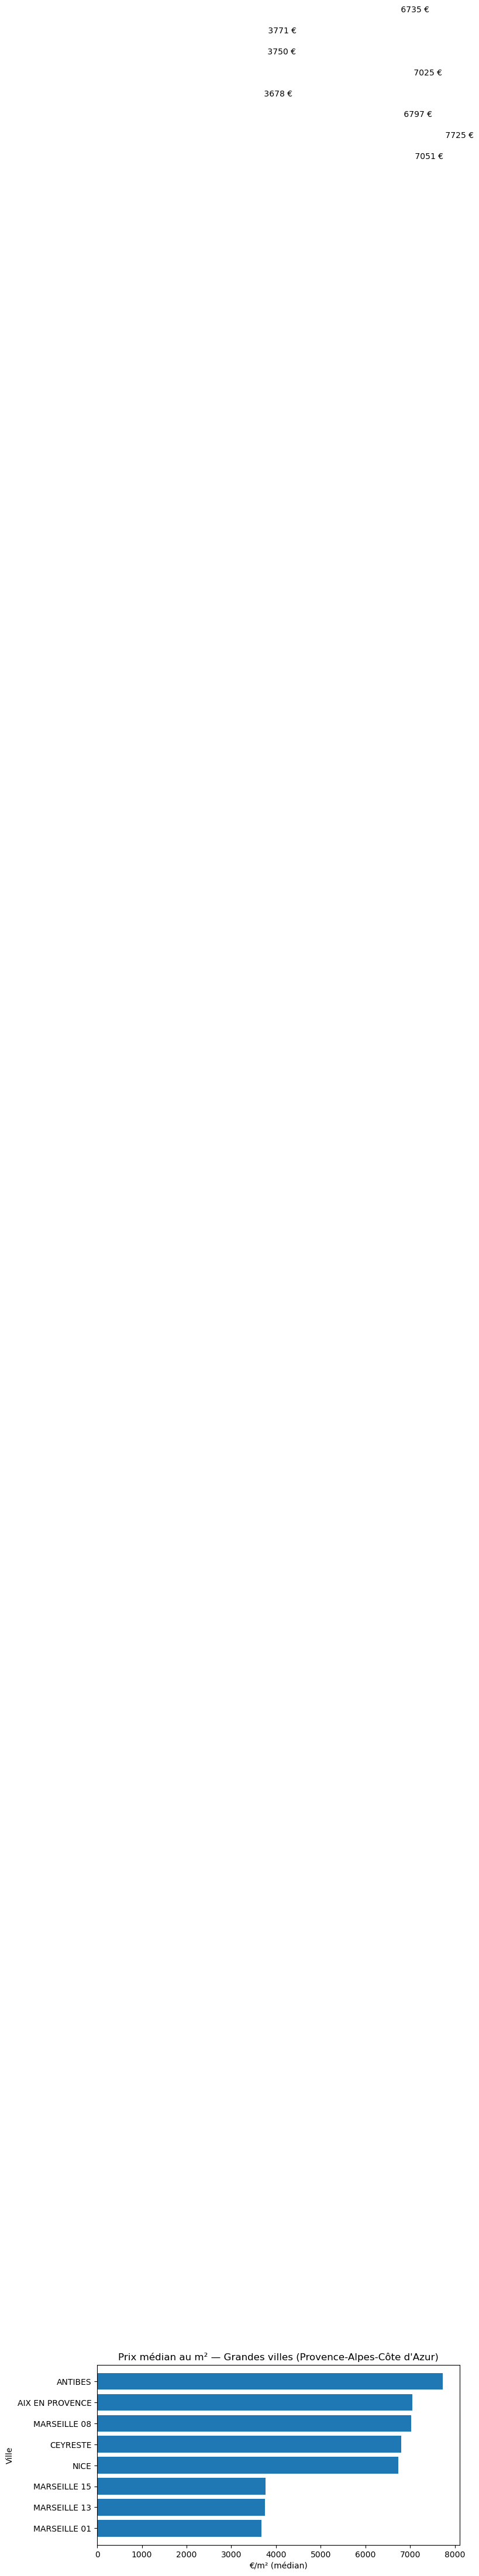

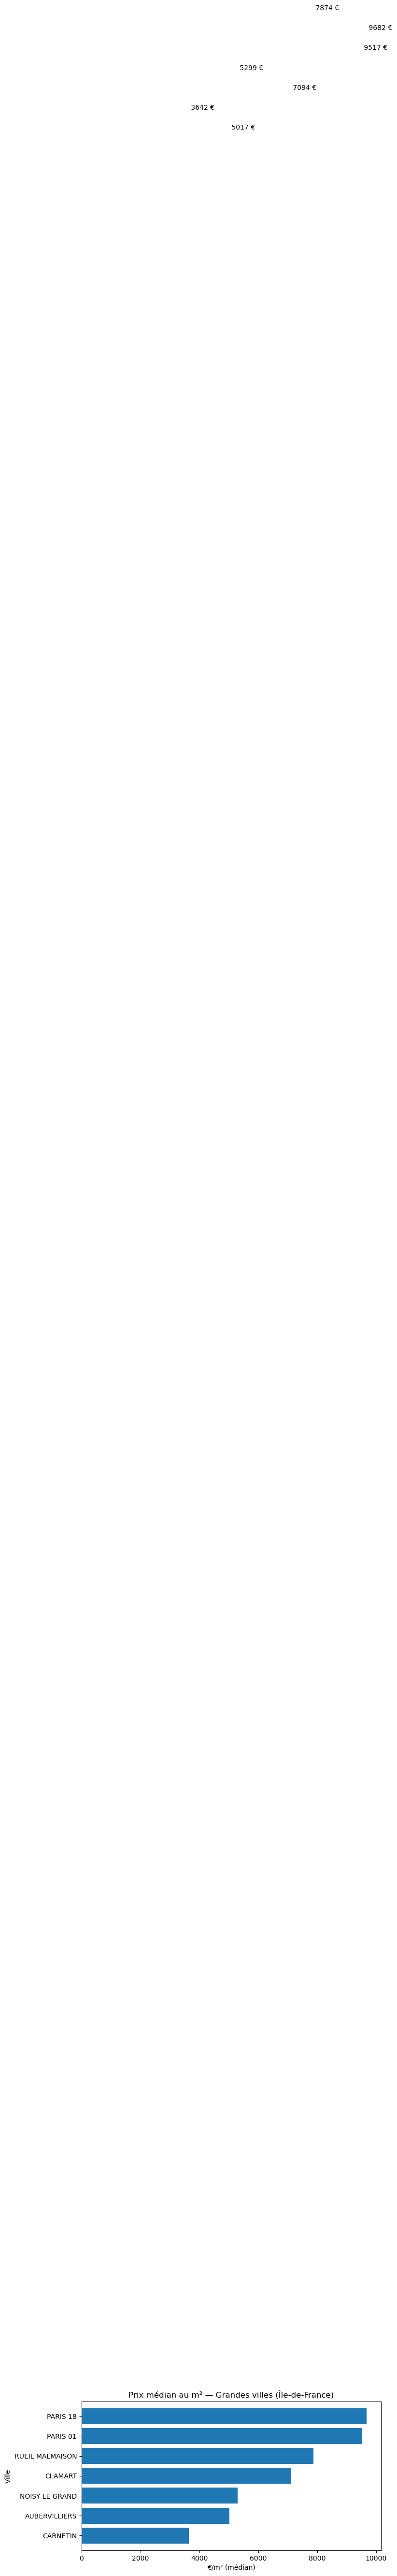

In [51]:
import matplotlib.pyplot as plt

for region in stats_city["region"].unique():
    df_r = (
        stats_city[stats_city["region"] == region]
        .sort_values("price_m2_median", ascending=True)
    )

    if len(df_r) < 2:
        continue

    fig, ax = plt.subplots(figsize=(8,4))
    ax.barh(df_r["ville_finale"], df_r["price_m2_median"])

    ax.set_title(f"Prix médian au m² — Grandes villes ({region})")
    ax.set_xlabel("€/m² (médian)")
    ax.set_ylabel("Ville")

    for i, row in df_r.iterrows():
        ax.text(row["price_m2_median"], i,
                f" {row['price_m2_median']:.0f} €",
                va="center")

    plt.tight_layout()
    plt.show()


## 6) Conclusion EDA 

En résumer:
- Qualité des données (NA, cohérence des champs prix/surface)
- Distributions (prix, surface, prix/m²)
- Différences géographiques (prix/m² par région / villes)
- Relation surface ↔ prix (corrélation + dispersion)

Ensuite, ces analyses sont reprises et rendues interactives dans le **dashboard Streamlit**.
